## 1. Comprendre les types de classification

La classification est une tâche d'apprentissage automatique qui consiste à attribuer une catégorie ou une classe à un élément. Il existe plusieurs types de classification, chacun adapté à des scénarios différents.

### Classification Binaire
La classification binaire est le type de classification le plus simple, où l'objectif est de prédire l'une des deux classes possibles. Ces deux classes sont souvent représentées par 0 et 1, ou par des étiquettes comme 'vrai'/'faux', 'oui'/'non'.

**Exemple:**
*   Détecter si un e-mail est du spam ou non spam.
*   Prédire si un patient a une maladie (positif) ou non (négatif).
*   Déterminer si une transaction financière est frauduleuse ou légitime.

### Classification Multiclasse
La classification multiclasse est une tâche où l'objectif est de prédire une classe parmi plus de deux classes mutuellement exclusives. Cela signifie qu'un élément ne peut appartenir qu'à une seule classe à la fois.

**Exemple:**
*   Classer des images d'animaux en 'chat', 'chien' ou 'oiseau'. Une image ne peut pas être à la fois un chat et un chien.
*   Reconnaissance de chiffres manuscrits (0 à 9).
*   Catégorisation d'articles de presse en 'sport', 'politique', 'économie', etc.

### Classification Multi-étiquettes
La classification multi-étiquettes est une tâche où un élément peut être associé à plusieurs étiquettes (classes) simultanément. Les classes ne sont pas mutuellement exclusives.

**Exemple:**
*   Attribuer des balises (tags) à un film : un film peut être 'action', 'science-fiction' et 'aventure' en même temps.
*   Classer une image en fonction de tous les objets qu'elle contient (par exemple, une image peut contenir 'personne', 'voiture', 'arbre').
*   Classer des documents par sujets : un document peut traiter simultanément de 'technologie' et de 'société'.

## 2. Configurez votre environnement Python et votre jeu de données.

Assurez-vous d'avoir installé les bibliothèques requises :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles

Il est temps de créer un ensemble de données sur lequel travailler :

In [2]:
samples = 1000
X, y = make_circles(samples,
                    noise = 0.03,
                    random_state = 42)

print('X : ', X)
print('\n')
print('y : ', y)

X :  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]


y :  [1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1

Visualisez l'ensemble de données à l'aide de nuages ​​de points pour comprendre la distribution des données.

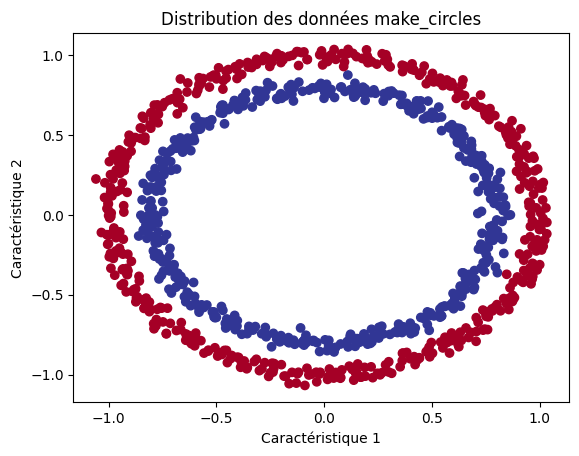

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Distribution des données make_circles")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.show()

## 3. Construire un modèle de réseau neuronal de base

Nous allons créer un modèle séquentiel dans TensorFlow avec une couche dense, utiliser l'entropie croisée binaire comme fonction de perte, entraîner le modèle et vérifier sa précision.

In [4]:
# Fixer la graine aléatoire pour la reproductibilité
tf.random.set_seed(42)

# 1. Créer un modèle séquentiel
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid') # Une seule couche dense avec une unité de sortie pour la classification binaire
])

# 2. Compiler le modèle
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(), # Utilisation de l'optimiseur SGD (Stochastic Gradient Descent)
                metrics=['accuracy'])

# 3. Entraîner le modèle
history_1 = model_1.fit(X, y, epochs=100, verbose=0) # Entraîner sur 100 époques, verbose=0 pour ne pas afficher la progression

# 4. Vérifier la précision (et la perte)
loss_1, accuracy_1 = model_1.evaluate(X, y)
print(f"Perte du modèle de base sur l'ensemble d'entraînement: {loss_1:.4f}")
print(f"Précision du modèle de base sur l'ensemble d'entraînement: {accuracy_1*100:.2f}%")

# Visualisation de l'historique d'entraînement (perte et précision au fil des époques)
# plt.plot(history_1.history['loss'], label='loss')
# plt.plot(history_1.history['accuracy'], label='accuracy')
# plt.title("Historique d'entraînement du modèle de base")
# plt.xlabel("Époques")
# plt.legend()
# plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4990 - loss: 0.6933  
Perte du modèle de base sur l'ensemble d'entraînement: 0.6933
Précision du modèle de base sur l'ensemble d'entraînement: 49.90%


## 4. Améliorer le modèle

Nous allons améliorer le modèle de base en ajoutant plus de couches et de neurones, en augmentant le nombre d'époques et en utilisant un optimiseur différent, comme Adam.

In [5]:
# Fixer la graine aléatoire pour la reproductibilité
tf.random.set_seed(42)

# 1. Créer un modèle séquentiel amélioré
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # Première couche cachée avec 10 neurones et activation ReLU
    tf.keras.layers.Dense(10, activation='relu'), # Deuxième couche cachée avec 10 neurones et activation ReLU
    tf.keras.layers.Dense(1, activation='sigmoid')  # Couche de sortie pour la classification binaire
])

# 2. Compiler le modèle
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(), # Utilisation de l'optimiseur Adam
                metrics=['accuracy'])

# 3. Entraîner le modèle
history_2 = model_2.fit(X, y, epochs=200, verbose=0) # Entraîner sur 200 époques

# 4. Vérifier la précision (et la perte)
loss_2, accuracy_2 = model_2.evaluate(X, y)
print(f"Perte du modèle amélioré sur l'ensemble d'entraînement: {loss_2:.4f}")
print(f"Précision du modèle amélioré sur l'ensemble d'entraînement: {accuracy_2*100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0058
Perte du modèle amélioré sur l'ensemble d'entraînement: 0.0058
Précision du modèle amélioré sur l'ensemble d'entraînement: 100.00%


## 5. Visualiser la frontière de décision

Nous allons maintenant implémenter une fonction `plot_decision_boundary()` pour visualiser les prédictions du modèle et la comparer pour les différents modèles.

In [6]:
# Fonction pour tracer la frontière de décision (réutilisable)
def plot_decision_boundary(model, X, y):
  """
  Trace la frontière de décision créée par un modèle de classification.
  """
  # Définir la grille de min et max des axes X et Y
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Créer des prédictions à l'aide de la grille combinée
  X_grid = np.c_[xx.ravel(), yy.ravel()]
  y_pred_grid = model.predict(X_grid)

  # Remodeler les prédictions pour qu'elles aient la même forme que xx
  if len(y_pred_grid[0]) > 1: # Modèle multiclasse
    y_pred_grid = np.argmax(y_pred_grid, axis=1).reshape(xx.shape)
  else: # Modèle binaire
    y_pred_grid = np.round(y_pred_grid).reshape(xx.shape)

  # Tracer la frontière de décision
  plt.contourf(xx, yy, y_pred_grid, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())


### Visualisation de la frontière de décision pour le modèle de base (model_1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


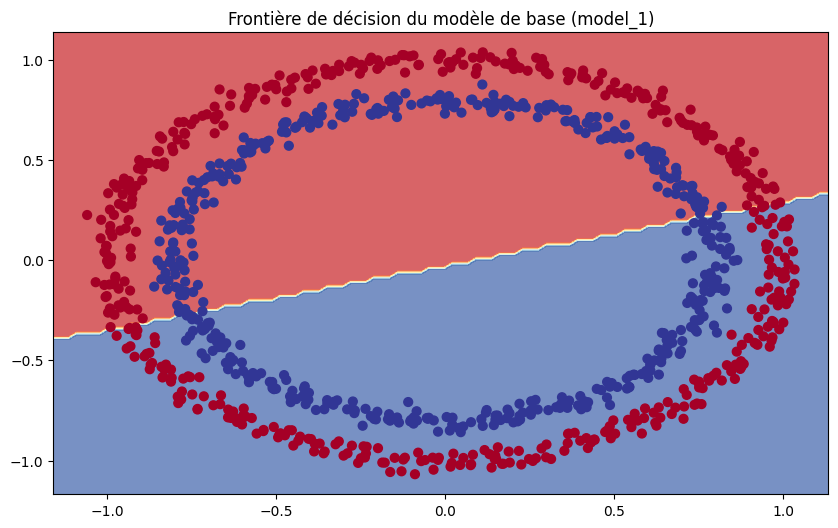

In [7]:
plt.figure(figsize=(10, 6))
plt.title("Frontière de décision du modèle de base (model_1)")
plot_decision_boundary(model_1, X, y)
plt.show()


### Visualisation de la frontière de décision pour le modèle amélioré (model_2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


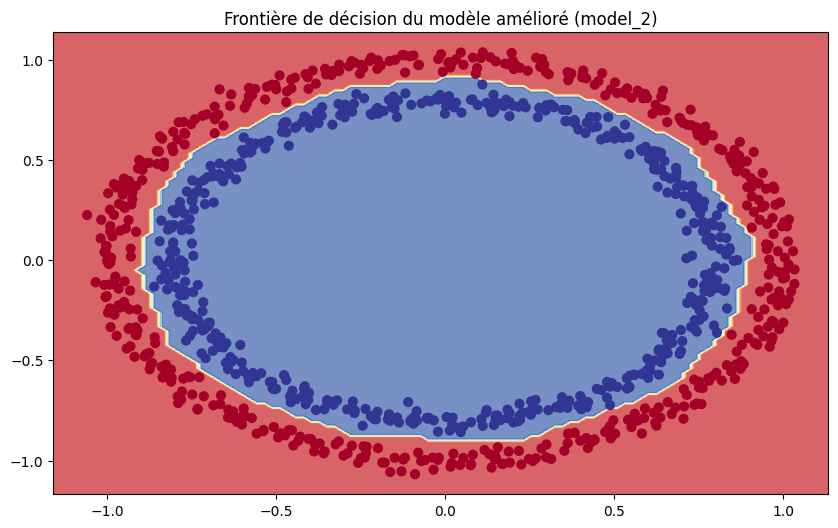

In [8]:
plt.figure(figsize=(10, 6))
plt.title("Frontière de décision du modèle amélioré (model_2)")
plot_decision_boundary(model_2, X, y)
plt.show()

## 7. Diviser les données en ensembles d'entraînement et de test

Nous allons diviser nos données en 80% pour l'entraînement et 20% pour les tests afin d'évaluer les performances du modèle sur des données non vues. Nous allons ensuite entraîner le modèle amélioré (model_2) sur l'ensemble d'entraînement et évaluer ses performances sur l'ensemble de test.

In [9]:
from sklearn.model_selection import train_test_split

# Diviser les données en ensembles d'entraînement et de test (80% entraînement, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Taille de l'ensemble d'entraînement X: {X_train.shape}")
print(f"Taille de l'ensemble de test X: {X_test.shape}")
print(f"Taille de l'ensemble d'entraînement y: {y_train.shape}")
print(f"Taille de l'ensemble de test y: {y_test.shape}")

# Réinitialiser le modèle amélioré (model_2) pour un nouvel entraînement sur les données divisées
tf.random.set_seed(42)
model_2_split = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_2_split.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                      optimizer=tf.keras.optimizers.Adam(),
                      metrics=['accuracy'])

# Entraîner le modèle sur l'ensemble d'entraînement
history_2_split = model_2_split.fit(X_train, y_train, epochs=200, verbose=0)

# Évaluer les performances du modèle sur l'ensemble de test
loss_2_test, accuracy_2_test = model_2_split.evaluate(X_test, y_test)
print(f"\nPerte du modèle amélioré sur l'ensemble de test: {loss_2_test:.4f}")
print(f"Précision du modèle amélioré sur l'ensemble de test: {accuracy_2_test*100:.2f}%")

Taille de l'ensemble d'entraînement X: (800, 2)
Taille de l'ensemble de test X: (200, 2)
Taille de l'ensemble d'entraînement y: (800,)
Taille de l'ensemble de test y: (200,)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0315  

Perte du modèle amélioré sur l'ensemble de test: 0.0315
Précision du modèle amélioré sur l'ensemble de test: 100.00%


## 8. Évaluer et visualiser les performances du modèle final

Nous allons vérifier la perte et la précision du modèle sur l'ensemble de test, puis utiliser la fonction `plot_decision_boundary()` pour visualiser les prédictions pour les données d'entraînement et de test. Enfin, nous comparerons les résultats et analyserons les améliorations.

### Évaluation sur l'ensemble de test

In [10]:
# Les résultats de l'évaluation sur l'ensemble de test ont déjà été affichés à la fin de l'étape 7
# loss_2_test, accuracy_2_test = model_2_split.evaluate(X_test, y_test)
# print(f"Perte du modèle amélioré sur l'ensemble de test: {loss_2_test:.4f}")
# print(f"Précision du modèle amélioré sur l'ensemble de test: {accuracy_2_test*100:.2f}%")

# Nous allons plutôt visualiser les frontières de décision sur les ensembles d'entraînement et de test.

### Visualisation des frontières de décision sur les ensembles d'entraînement et de test

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


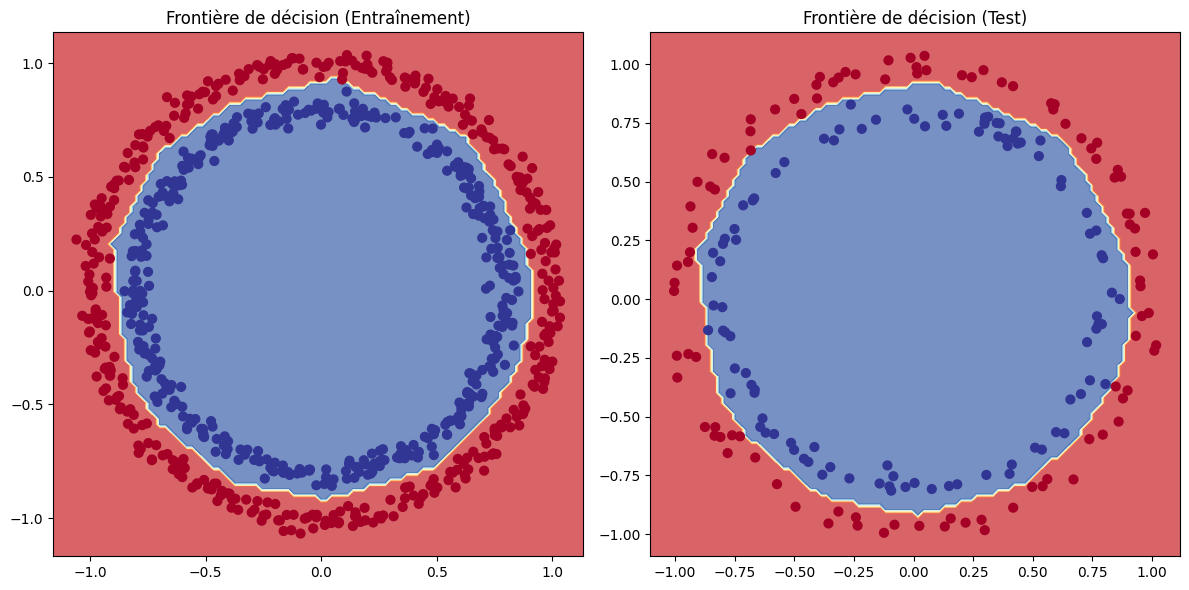

In [11]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Frontière de décision (Entraînement)")
plot_decision_boundary(model_2_split, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Frontière de décision (Test)")
plot_decision_boundary(model_2_split, X_test, y_test)

plt.tight_layout()
plt.show()

## 9. Résumer les points clés

Nous allons maintenant résumer ce que nous avons appris, en soulignant l'importance de la visualisation des données et du réglage des hyperparamètres pour améliorer les modèles de classification.

### Résumé des points clés

*   **Comprendre les types de classification :** Nous avons vu les différences entre la classification binaire, multiclasse et multi-étiquettes, essentielles pour choisir les bonnes approches et fonctions de perte.

*   **Importance de la visualisation des données :** La visualisation initiale de l'ensemble de données `make_circles` a clairement montré que les données n'étaient pas linéairement séparables. Cela a été un indice clé que des modèles plus complexes, avec des fonctions d'activation non linéaires, seraient nécessaires.

*   **Construction progressive du modèle :**
    *   Un modèle de base (`model_1`) avec une seule couche dense et une activation `sigmoid` a obtenu une précision très faible (~50%), incapable de séparer les cercles.
    *   L'amélioration du modèle (`model_2` et `model_2_split`) en ajoutant des couches cachées avec des fonctions d'activation `ReLU` et en utilisant un optimiseur `Adam` a permis d'atteindre une précision de 100%. Cela démontre la capacité des réseaux de neurones profonds à apprendre des relations non linéaires.

*   **Rôle crucial des fonctions d'activation :** Les fonctions d'activation non linéaires comme `ReLU` sont fondamentales pour permettre aux réseaux de neurones d'apprendre des motifs complexes et de former des frontières de décision non linéaires, comme on l'a observé avec les cercles.

*   **Optimiseurs :** Le passage de SGD à Adam a contribué à une convergence plus rapide et à de meilleures performances, soulignant l'importance de choisir un optimiseur adapté.

*   **Division en ensembles d'entraînement et de test :** Séparer les données en ensembles d'entraînement et de test est essentiel pour obtenir une évaluation réaliste des performances du modèle sur des données non vues. Nos modèles entraînés sur les données complètes ont montré une précision élevée, et l'évaluation sur l'ensemble de test a confirmé cette bonne performance.

*   **Visualisation des frontières de décision :** La fonction `plot_decision_boundary()` a été un outil puissant pour comprendre visuellement comment chaque modèle tentait de classer les points, mettant en évidence l'efficacité du modèle amélioré à créer une frontière complexe.

Ce défi a illustré le processus itératif de construction et d'amélioration d'un modèle de classification, depuis la compréhension des données jusqu'à l'évaluation finale et la visualisation des résultats, en soulignant l'impact des choix d'architecture et d'hyperparamètres.